In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import math
import seaborn as sns

In [8]:
df = pd.read_csv('credit_risk_dataset.csv')
print(f'{df.shape[0]:,} Rows X {df.shape[1]:,} Columns')
print(f'\nDataset Information')
print(f'{df.info()}')

32,581 Rows X 12 Columns

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory 

In [11]:
print('Checking if any column contains missing values.')
print(df.isnull().any()[df.isnull().any() == True])

df.dropna(axis=0, inplace=True)

print('\nAfter dropping Missing Values')
print(df.isnull().any()[df.isnull().any() == True])

Checking if any column contains missing values.
Series([], dtype: bool)

After dropping Missing Values
Series([], dtype: bool)


In [13]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categrocial_cols = df.select_dtypes(include=['object']).columns.tolist()

if 'loan_status' in numerical_cols:
    numerical_cols.remove('loan_status')
elif 'loan_status' in categrocial_cols:
    categrocial_cols.remove('loan_status')

print(numerical_cols)
print(categrocial_cols)


['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


Percentage of non-defaults and defautls

78.34% : Non Defaults
21.66% : Defaults


Text(0.5, 1.0, 'Pie Chart: Non Defaults vs Defaults')

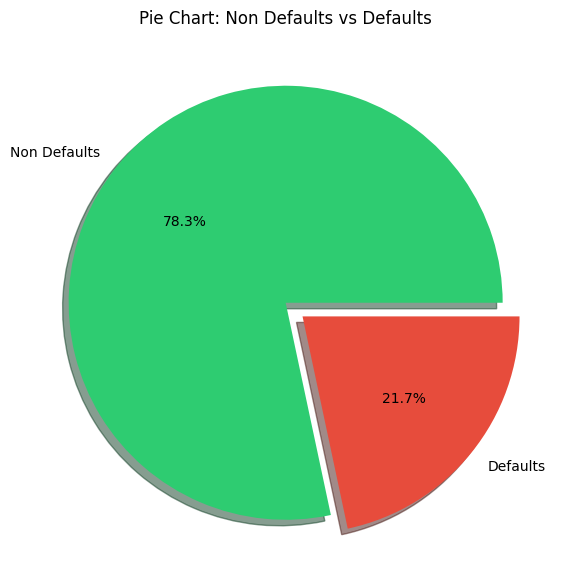

In [52]:

percentage_target_count = df['loan_status'].value_counts(normalize=True)*100

print('Percentage of non-defaults and defautls\n')
print(f'{percentage_target_count[0]:.2f}% : Non Defaults')
print(f'{percentage_target_count[1]:.2f}% : Defaults')

plt.figure(figsize=(7,8))
plt.pie(percentage_target_count.values, labels = ['Non Defaults', 'Defaults'], explode=(0,0.1), shadow=True,
        colors=['#2ecc71', '#e74c3c'],autopct='%1.1f%%')
plt.title('Pie Chart: Non Defaults vs Defaults')

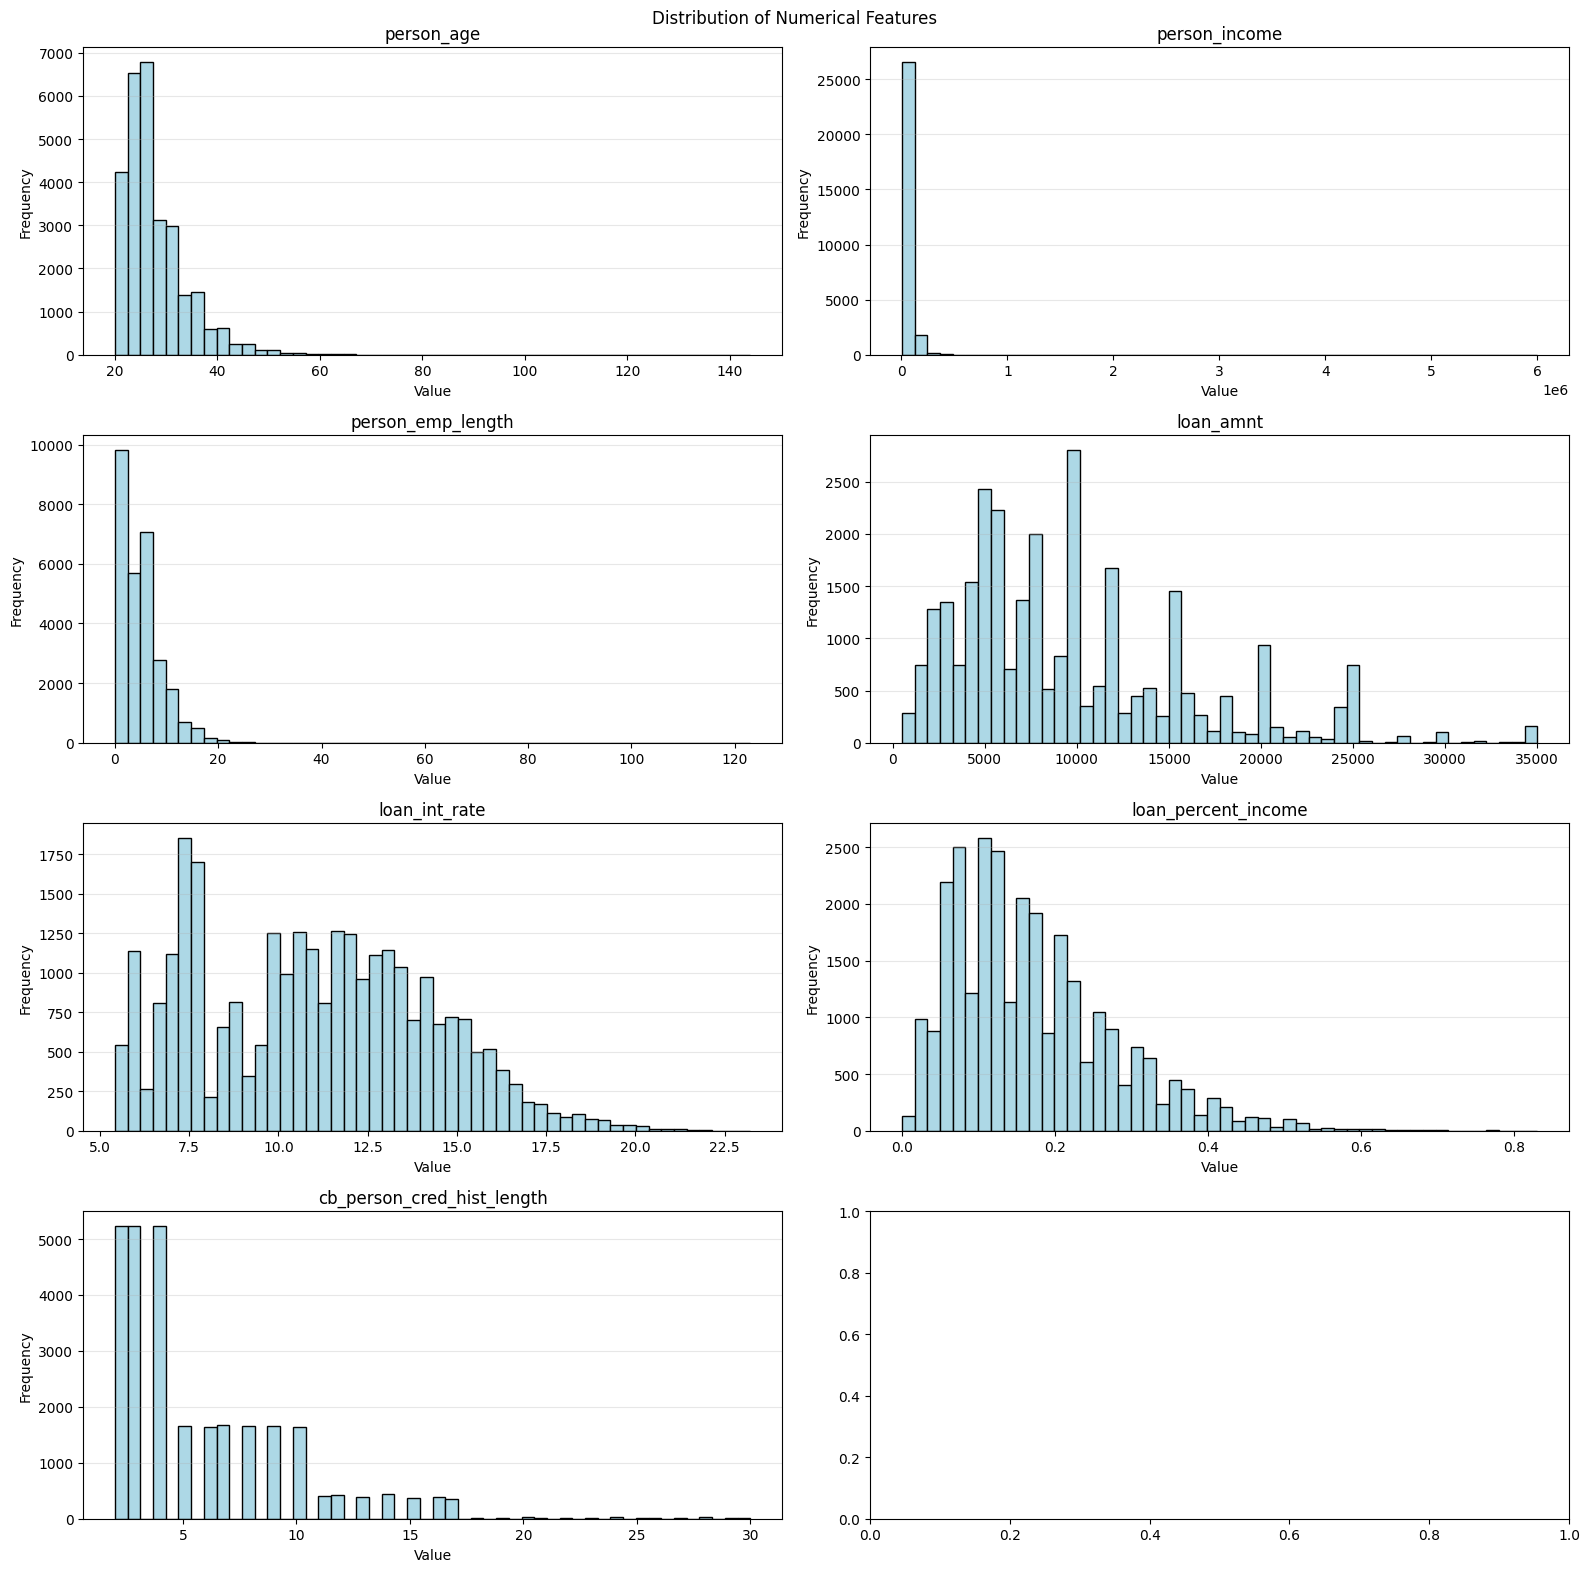

In [97]:
cols = 2
rows = math.ceil(len(numerical_cols)/2)

fig, axes = plt.subplots(rows, cols, figsize = (16, rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins = 50, color='Lightblue', edgecolor='Black')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)


plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

In [84]:
for col in categrocial_cols:
    print(f'\n{df[col].value_counts()}')


person_home_ownership
RENT        14551
MORTGAGE    11801
OWN          2192
OTHER          94
Name: count, dtype: int64

loan_intent
EDUCATION            5704
MEDICAL              5293
VENTURE              5001
PERSONAL             4877
DEBTCONSOLIDATION    4565
HOMEIMPROVEMENT      3198
Name: count, dtype: int64

loan_grade
A    9402
B    9151
C    5699
D    3248
E     870
F     209
G      59
Name: count, dtype: int64

cb_person_default_on_file
N    23535
Y     5103
Name: count, dtype: int64


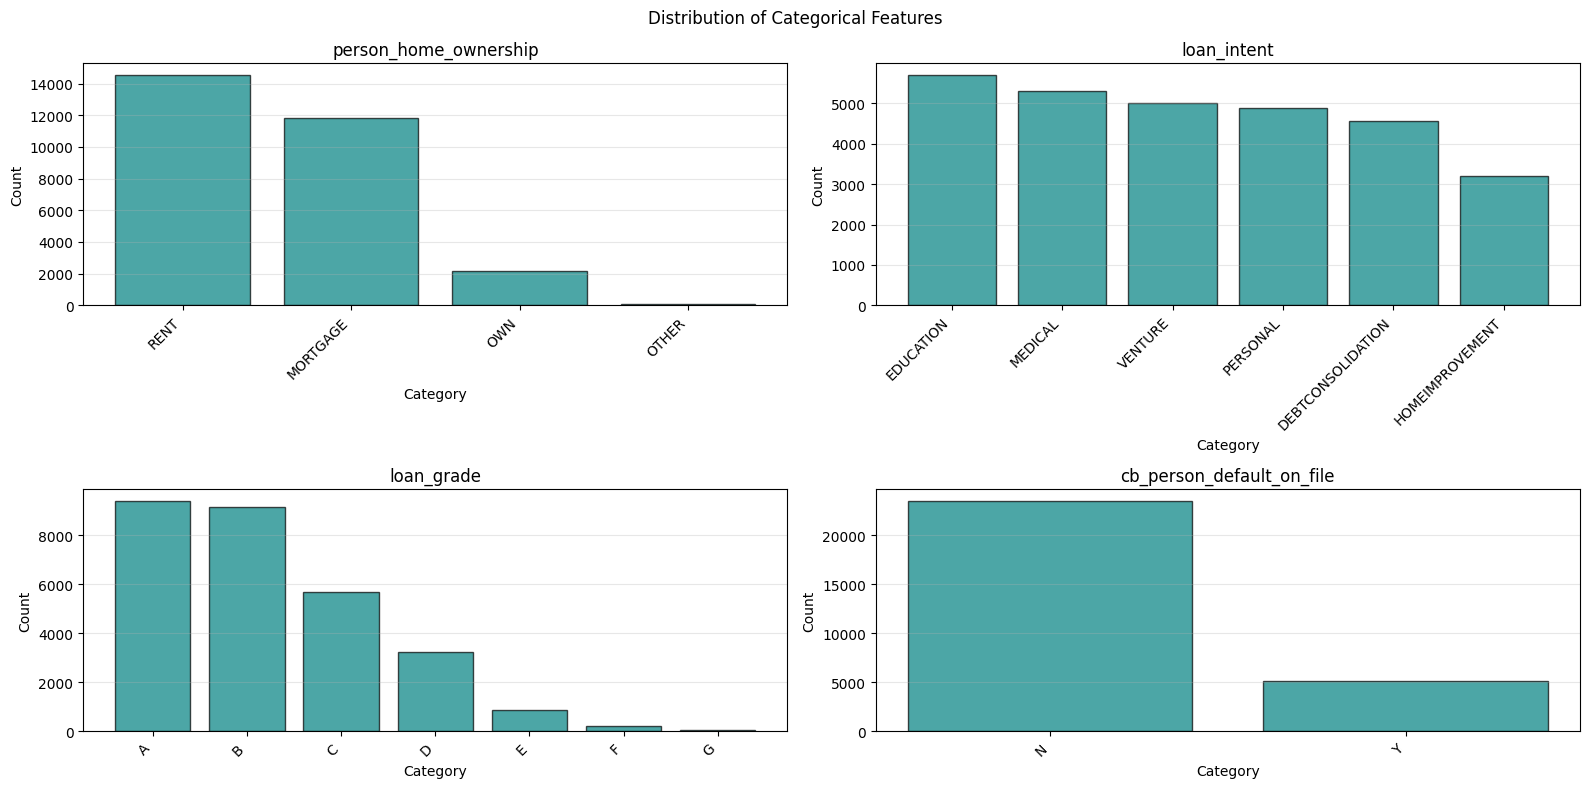

In [105]:
cols = 2
rows = math.ceil(len(categrocial_cols)/2)

fig, axes = plt.subplots(rows, cols, figsize = (16, rows * 4))
axes = axes.flatten()

for idx, col in enumerate(categrocial_cols):
    value_counts = df[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values, color= 'Teal', edgecolor= 'Black', alpha=0.7)
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Category')
    axes[idx].set_ylabel('Count')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Distribution of Categorical Features')
plt.tight_layout()
plt.show()

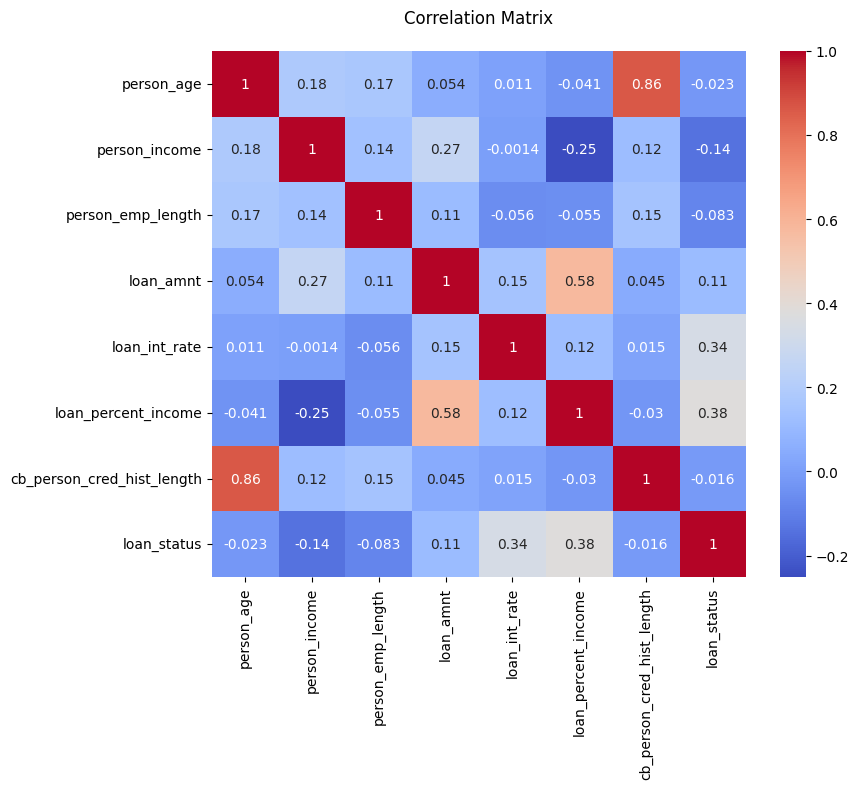

In [117]:
corr_matrix = df[numerical_cols + ['loan_status']].corr()

plt.figure(figsize=(9, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix', pad=20)
plt.tight_layout()
plt.show()

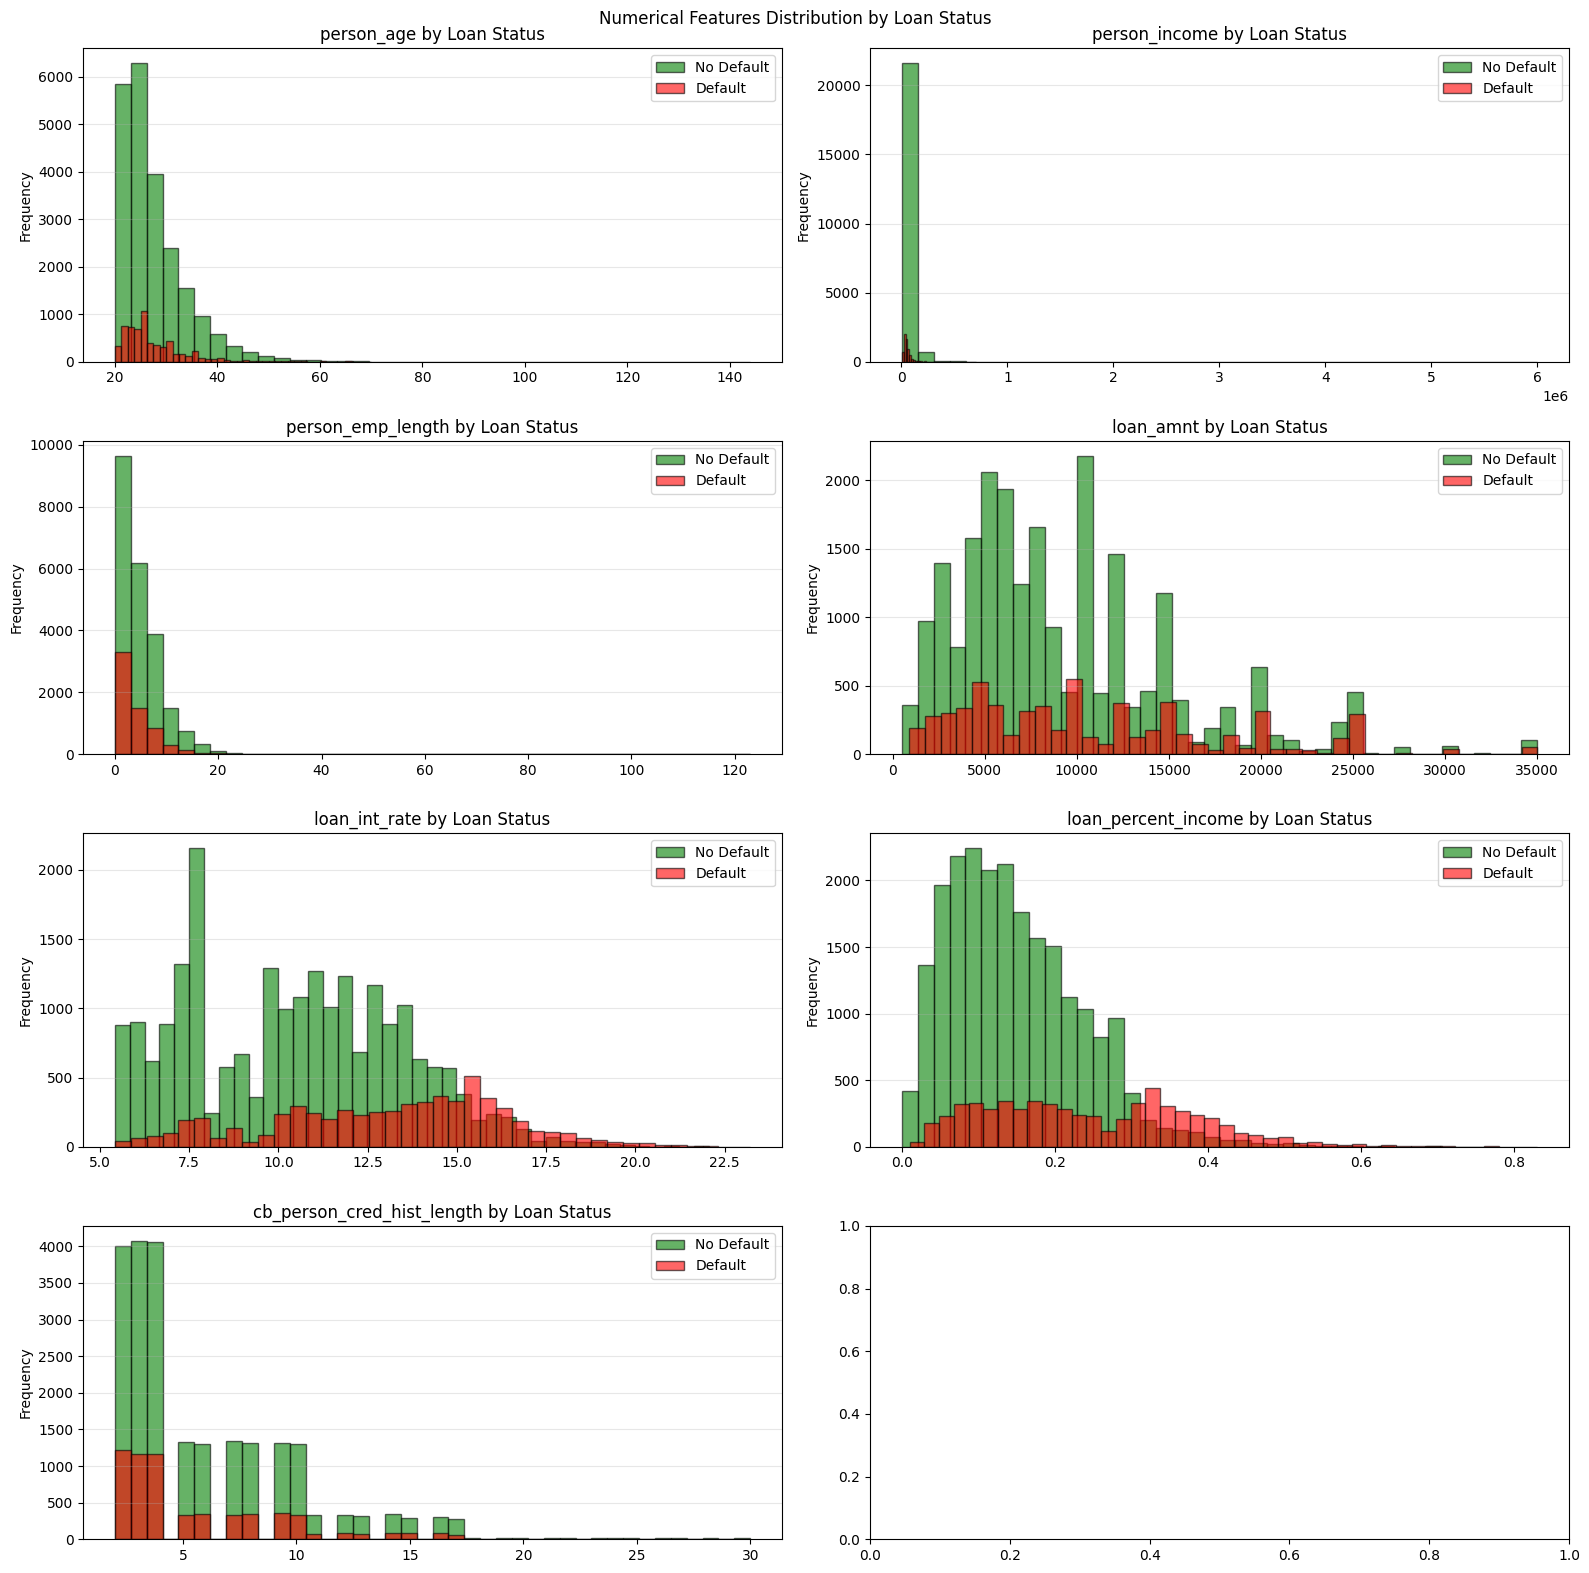

In [121]:
cols = 2
rows = math.ceil(len(numerical_cols)/2)

fig, axes = plt.subplots(rows, cols, figsize = (16, rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):

    no_default = df[df['loan_status'] == 0][col].dropna()
    default = df[df['loan_status'] == 1][col].dropna()

    axes[idx].hist(no_default, bins=40, alpha=0.6, label='No Default', color='green', edgecolor='black')
    axes[idx].hist(default, bins=40, alpha=0.6, label='Default', color='red', edgecolor='black')

    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{col} by Loan Status')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Numerical Features Distribution by Loan Status')
plt.tight_layout()
plt.show()


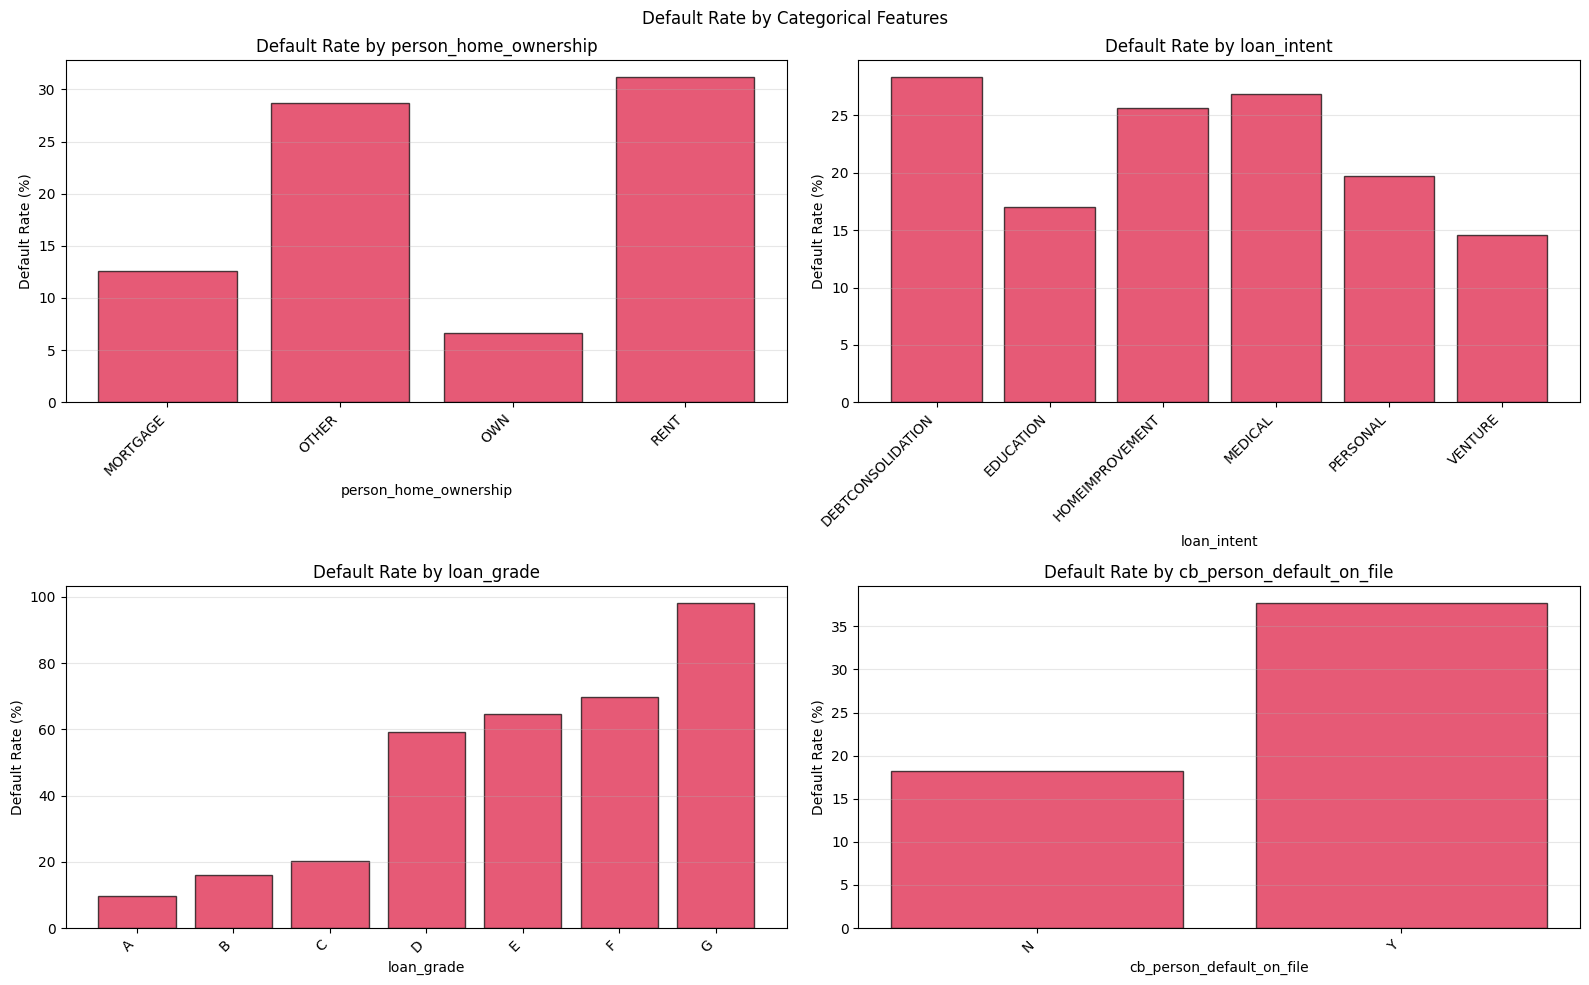

In [128]:
cols = 2
rows = math.ceil(len(categrocial_cols)/2)

fig, axes = plt.subplots(rows, cols, figsize = (16, rows * 5))
axes = axes.flatten()

for idx, col in enumerate(categrocial_cols):
    default_rate = df.groupby(col)['loan_status'].mean()*100
    axes[idx].bar(range(len(default_rate)), default_rate.values, color='crimson', alpha=0.7, edgecolor='black')
    axes[idx].set_xticks(range(len(default_rate)))
    axes[idx].set_xticklabels(default_rate.index, rotation=45, ha='right')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Default Rate (%)')
    axes[idx].set_title(f'Default Rate by {col}')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Default Rate by Categorical Features')
plt.tight_layout()
plt.show()